# Tilt Census

Counts and distributions of tilt distance and direction by eddy type and region.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import seacofs_tilt_tools as tilt

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df_eddies, df_tilt = tilt.load_tilt_tables(paths, add_regions=True, grid=grid)

region_group_map = {"S1": "Shelf", "S2": "Shelf", "U1": "Upstream", "U2": "Upstream", "D1": "Downstream", "D2": "Downstream"}
df_eddies["RegionGroup"] = df_eddies.Region.map(region_group_map)
df_eddies.head()


,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,psi0,AR,R,Age,Date,fname,TiltDis,TiltDir,Region,RegionGroup
0,1,1462,CE,152.716333,-38.866383,171,26,474.560686,127.605656,-0.000032,...,7.225911,1.973172,20.004291,26,1994-01-02,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,D1,Downstream
1,1,1463,CE,152.836206,-38.814279,173,28,482.821993,136.635735,-0.000041,...,7.225911,1.859668,18.906549,26,1994-01-03,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,D1,Downstream
2,1,1464,CE,152.905198,-38.816261,175,28,488.606048,138.480541,-0.000035,...,7.712683,1.745185,20.859920,26,1994-01-04,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,D1,Downstream
3,1,1465,CE,152.719389,-38.902070,171,25,475.960098,123.953440,-0.000020,...,8.275696,1.433213,18.674495,26,1994-01-05,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,19.823350,87.507772,D1,Downstream
4,1,1466,CE,152.753007,-38.935135,172,25,479.803789,121.483614,-0.000026,...,8.838709,1.140614,21.564028,26,1994-01-06,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,15.055658,105.302388,D1,Downstream


In [2]:
for cyc in ['AE', 'CE']:

    df = df_eddies[df_eddies.Cyc == cyc]

    n_eddies = df.Eddy.nunique()
    n_eddy_days = len(df)
    n_tilt = df.TiltDis.notna().sum()

    print(f'No. {cyc}s               : {n_eddies:,}')
    print(f'No. {cyc} eddy-days     : {n_eddy_days:,}')
    print(f'No. {cyc} tilt estimates: {n_tilt:,}')
    print(f'Tilt success rate       : {100*n_tilt/(n_eddy_days-6*n_eddies):.1f}%')
    print()

n_eddies = df_eddies.Eddy.nunique()
n_eddy_days = len(df_eddies)
n_tilt = df_eddies.TiltDis.notna().sum()

print(f'Total eddies        : {n_eddies:,}')
print(f'Total eddy-days     : {n_eddy_days:,}')
print(f'Total tilt estimates: {n_tilt:,}')
print(f'Tilt success rate   : {100*n_tilt/(n_eddy_days-6*n_eddies):.1f}%')

No. AEs               : 1,446
No. AE eddy-days     : 64,952
No. AE tilt estimates: 53,607
Tilt success rate       : 95.3%

No. CEs               : 1,536
No. CE eddy-days     : 62,474
No. CE tilt estimates: 52,014
Tilt success rate       : 97.7%

Total eddies        : 2,982
Total eddy-days     : 127,426
Total tilt estimates: 105,621
Tilt success rate   : 96.4%


In [3]:
census = (
    df_eddies
    .groupby(["Cyc", "RegionGroup"], dropna=False)
    .agg(eddy_days=("Eddy", "size"), unique_eddies=("Eddy", "nunique"), tilt_days=("TiltDis", "count"), median_tilt=("TiltDis", "median"), mean_dir=("TiltDir", tilt.circular_mean_deg_true_north))
    .reset_index()
)
census


,Cyc,RegionGroup,eddy_days,unique_eddies,tilt_days,median_tilt,mean_dir
0,AE,Downstream,36552,880,30772,15.974914,NaN
1,AE,Shelf,8869,401,7065,17.441316,NaN
2,AE,Upstream,19529,595,15770,29.639669,NaN
3,AE,NaN,2,2,0,NaN,NaN
4,CE,Downstream,26285,792,22016,12.954576,NaN
5,CE,Shelf,13952,564,11322,11.958577,NaN
6,CE,Upstream,22237,609,18676,23.636240,NaN


In [4]:
def eddy_summary(g):
    if g.empty:
        return None

    tdir = g.TiltDir.dropna()

    return pd.Series({
        'Cyc': g.Cyc.iloc[0],
        'ave_TDis': g.TiltDis.mean(),
        'min_TDis': g.TiltDis.min(),
        'max_TDis': g.TiltDis.max(),
        'ave_TDir': (
            tilt.circular_mean_deg_true_north(tdir)
            if len(tdir) > 0 else np.nan
        )
    })


df_eddy_data = (
    df_eddies
    .groupby('Eddy', group_keys=False)
    # .filter(lambda g: g.TiltDis.notna().sum() >= 30)
    # .groupby('Eddy')
    .apply(eddy_summary, include_groups=False)
    .reset_index()
    .dropna()
)


In [5]:
# fig, axs = plt.subplots(3, 1, figsize=(9, 8), constrained_layout=True)
# metrics = [("TiltDis", "Tilt distance (km)"),
#            ("Age", "Age (days)"),
#            ("Rc", "Radius (km)")]
# for ax, (col, xlabel) in zip(axs, metrics):
#     ae = df_eddies.loc[df_eddies.Cyc == "AE", col].dropna()
#     ce = df_eddies.loc[df_eddies.Cyc == "CE", col].dropna()
#     bins = tilt.shared_bins(ae, ce)
#     tilt.mirrored_hist(ax, ae, ce, bins, xlabel)
# axs[0].legend(frameon=False)
# plt.show()


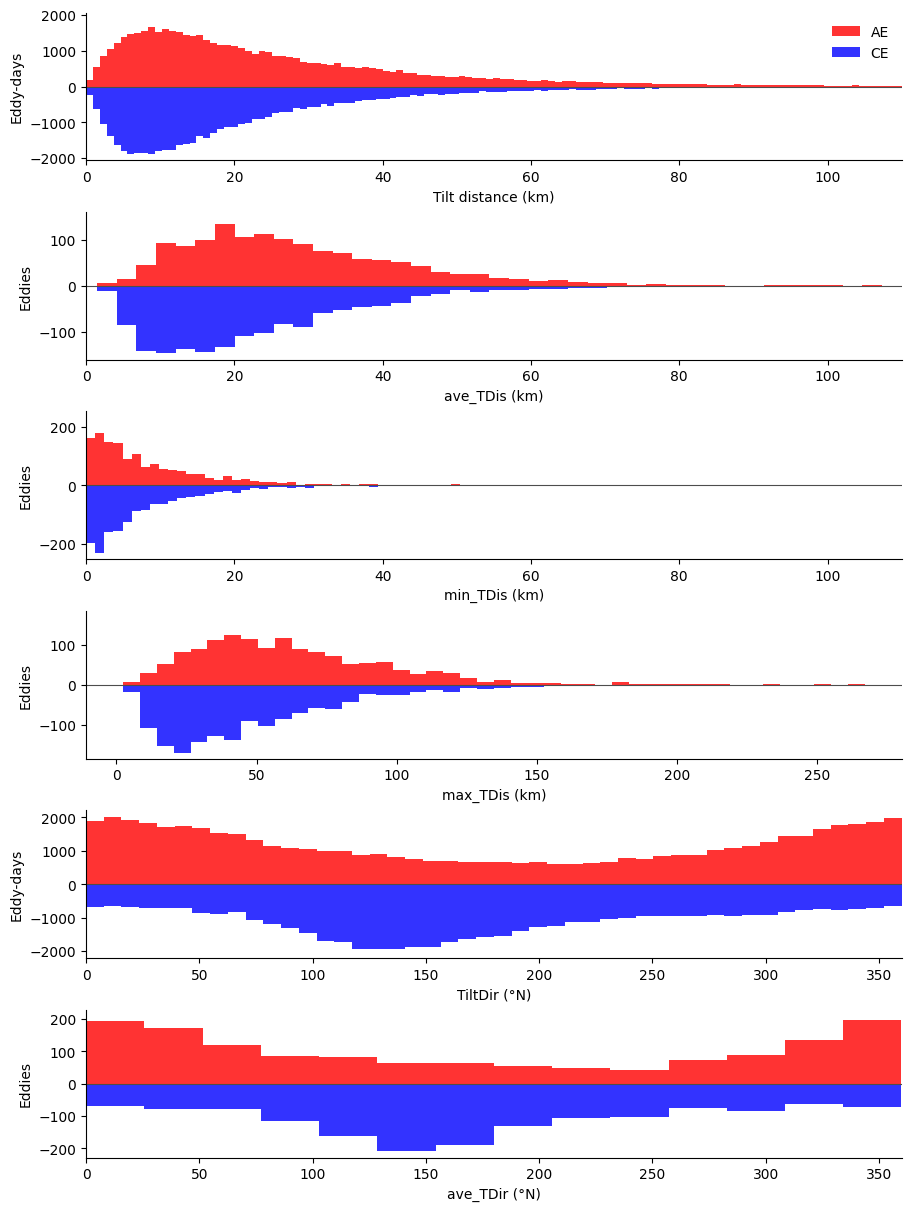

In [6]:
fig, axs = plt.subplots(6, 1, figsize=(9, 12), constrained_layout=True)
metrics = [("TiltDis", "Tilt distance (km)", (0,110)),
           ("ave_TDis", "ave_TDis (km)", (0,110)),
           ("min_TDis", "min_TDis (km)", (0,110)),
           ("max_TDis", "max_TDis (km)", None),
           ("TiltDir", "TiltDir (°N)", (0,360)),
           ("ave_TDir", "ave_TDir (°N)", (0,360))]

for ax, (col, xlabel, xlim) in zip(axs, metrics):
    if col in ['ave_TDis', 'min_TDis', 'max_TDis', 'ave_TDir']:
        df = df_eddy_data.copy()
        ylabel = 'Eddies'
    else:
        df = df_eddies.copy()
        ylabel = 'Eddy-days'
    ae = df.loc[df.Cyc == "AE", col].dropna()
    ce = df.loc[df.Cyc == "CE", col].dropna()
    bins = tilt.shared_bins(ae, ce)
    
    tilt.mirrored_hist(ax, ae, ce, bins, xlabel, xlim=xlim, ylabel=ylabel)
axs[0].legend(frameon=False)
plt.show()


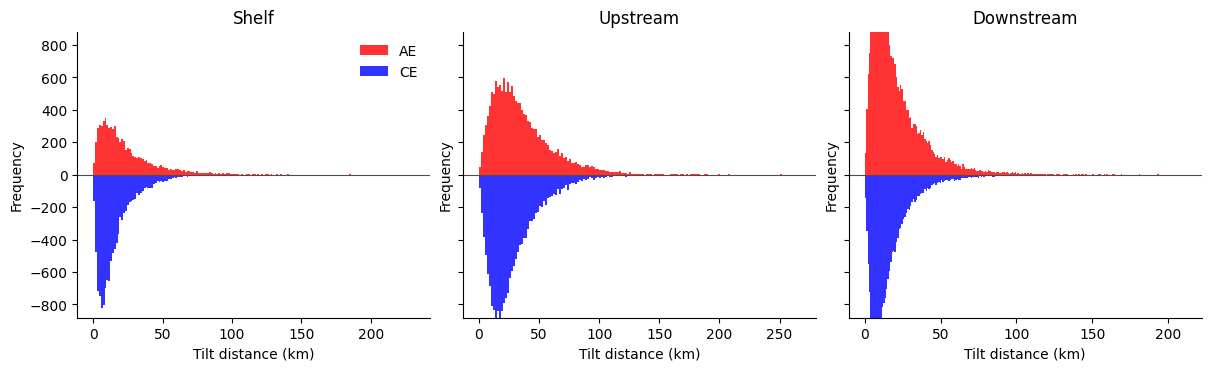

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True, constrained_layout=True)
for ax, region in zip(axs, ["Shelf", "Upstream", "Downstream"]):
    subset = df_eddies.loc[df_eddies.RegionGroup == region]
    ae = subset.loc[subset.Cyc == "AE", "TiltDis"].dropna()
    ce = subset.loc[subset.Cyc == "CE", "TiltDis"].dropna()
    bins = tilt.shared_bins(ae, ce)
    tilt.mirrored_hist(ax, ae, ce, bins, "Tilt distance (km)")
    ax.set_title(region)
axs[0].legend(frameon=False)
plt.show()
